In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [8]:
fs = 1000 # Hz
duration = 5 #s

t = np.arange(0, duration, 1/fs)

f1 = 10
f2 = 50
f3 = 120

x = (
    1.0 * np.sin(2 * np.pi * f1 * t) +
    0.5 * np.sin(2 * np.pi * f2 * t) + 
    0.25 * np.sin(2 * np.pi * f3 * t)
)

# add random noise

np.random.seed(42)
noise = 0.2 * np.random.randn(len(t))

x_noisy = x + noise

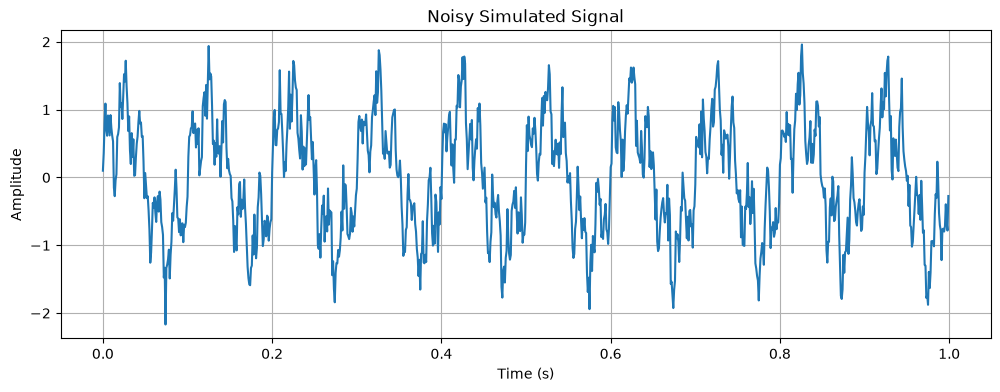

In [9]:
plt.figure(figsize=(12, 4))

plt.plot(t[:1000], x_noisy[:1000])

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Noisy Simulated Signal")
plt.grid(True)
plt.show()

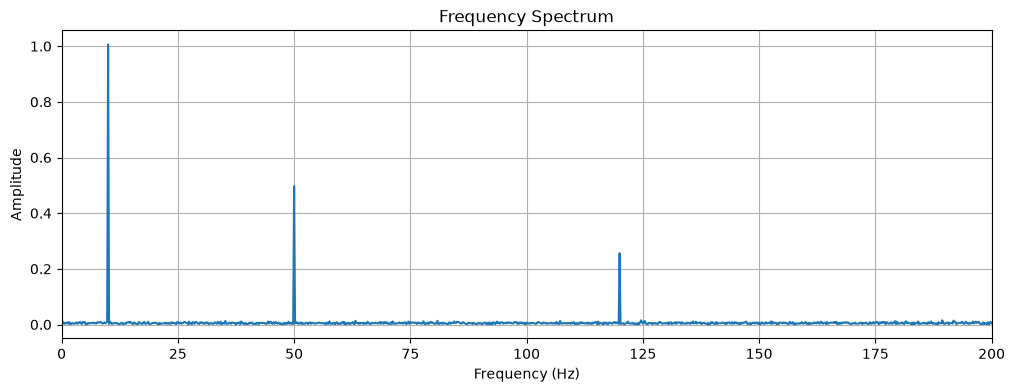

In [10]:
N = len(x_noisy)

X = np.fft.rfft(x_noisy)
freqs = np.fft.rfftfreq(N, 1/fs)
magnitude = np.abs(X) / N
magnitude[1:-1] *= 2

plt.figure(figsize = (12, 4))

plt.plot(freqs, magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel('Amplitude')
plt.title('Frequency Spectrum')
plt.xlim(0, 200)
plt.grid(True)
plt.show()

In [11]:
# spectral leakage
f4 = 73.3  # Hz

x_leakage = (
    1.0 * np.sin(2 * np.pi * f4 * t)
)

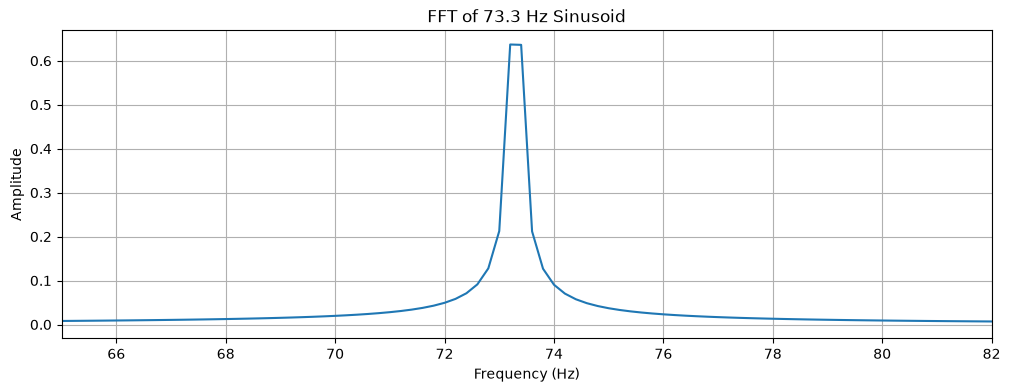

In [12]:
N = len(x_leakage)

X = np.fft.rfft(x_leakage)
freqs = np.fft.rfftfreq(N, 1 / fs)

magnitude = np.abs(X) / N
magnitude[1:-1] *= 2

plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitude)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT of 73.3 Hz Sinusoid")
plt.xlim(65, 82)
plt.grid(True)
plt.show()

In [15]:
# spectral leakage fix with smaller bins over longer duration
f4 = 73.3  # Hz
t = np.arange(0, 10, 1/fs)
x_leakage = (
    1.0 * np.sin(2 * np.pi * f4 * t)
)

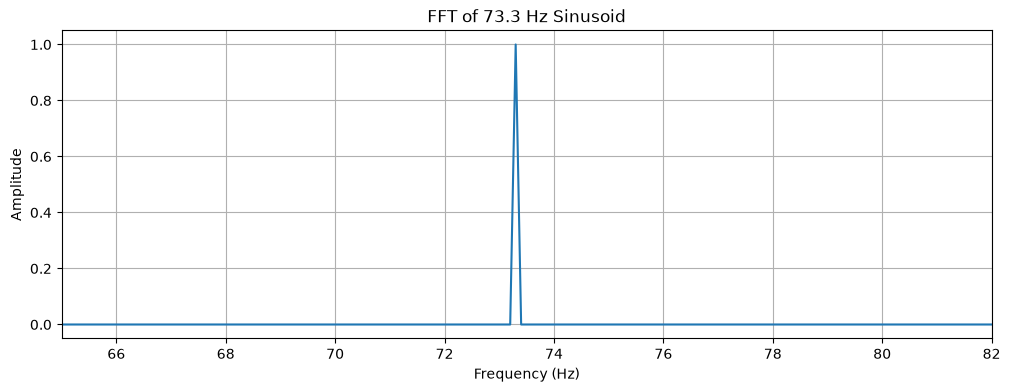

In [16]:
N = len(x_leakage)

X = np.fft.rfft(x_leakage)
freqs = np.fft.rfftfreq(N, 1 / fs)

magnitude = np.abs(X) / N
magnitude[1:-1] *= 2

plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitude)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT of 73.3 Hz Sinusoid")
plt.xlim(65, 82)
plt.grid(True)
plt.show()

In [17]:
fs = 1000
duration = 5

t = np.arange(0, duration, 1 / fs)

f = 73.3

x = np.sin(2 * np.pi * f * t)

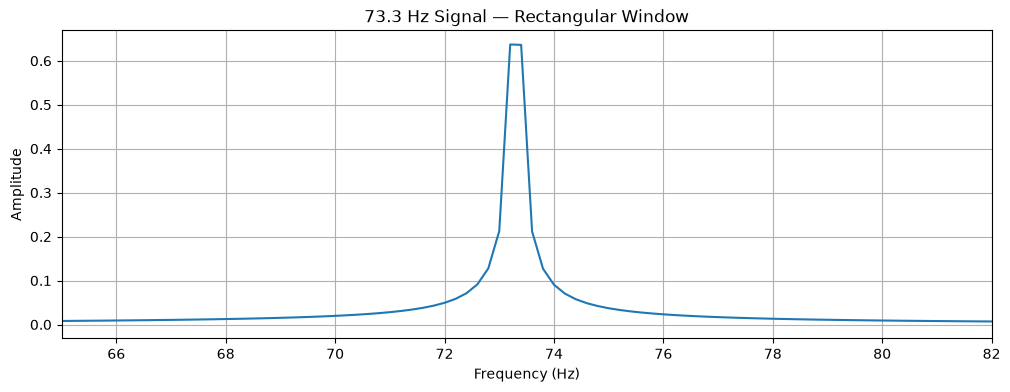

In [18]:
N = len(x)

X = np.fft.rfft(x)
freqs = np.fft.rfftfreq(N, 1 / fs)

magnitude = np.abs(X) / N
magnitude[1:-1] *= 2

plt.figure(figsize=(12, 4))

plt.plot(freqs, magnitude)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("73.3 Hz Signal — Rectangular Window")
plt.xlim(65, 82)
plt.grid(True)
plt.show()

In [19]:
window = np.hanning(N)

x_windowed = x * window

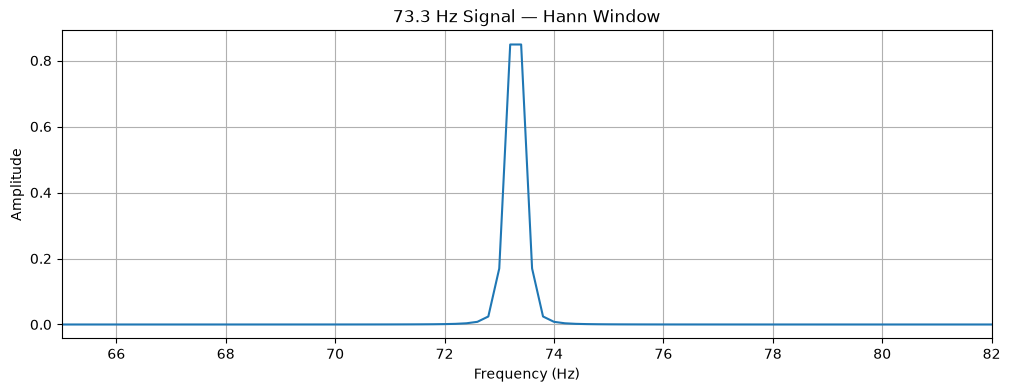

In [21]:
X_windowed = np.fft.rfft(x_windowed)

magnitude_windowed = np.abs(X_windowed) / (N / 2)
magnitude_windowed[1:-1] *= 2
plt.figure(figsize=(12, 4))

plt.plot(freqs, magnitude_windowed)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("73.3 Hz Signal — Hann Window")
plt.xlim(65, 82)
plt.grid(True)
plt.show()